# 03 — Caso B: direzione condivisa, energia libera

**Assunzioni:** (1) sorgente unica; (2) direzione del neutrone circa costante (campo lontano);
scattering isotropo in CM. Il parametro condiviso è la direzione $\Omega_n$. L'energia $E_n$ di
ogni evento è una nuisance con prior largo (piatto su 0.5–6 MeV).

Per ogni direzione candidata $\Omega$, l'angolo osservato fra traccia e candidato è
$\hat\theta = \angle(\hat t_k, \Omega)$. La verosimiglianza marginalizza sia $E_n$ sia l'angolo vero
$\theta$:
$$L_k(\Omega) = \int d\theta \int dE_n\, \pi(E_n)\,\frac{\cos\theta}{\pi}\,
N(\hat\theta;\theta,\sigma_\theta)\, N(\hat E_p; E_n\cos^2\theta, \sigma_{E_p}).$$
Il termine $\cos\theta/\pi$ è la densità della traccia per steradiante (notebook 01).
L'approssimazione con errore polare gaussiano 1D è etichettata **(b)**.

**Etichette dei risultati.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite ·
(c) verificato con Monte Carlo · (d) ipotesi da testare.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.stats import kstest, norm

from riptide_toy.constants import SEED, SIGMA_EP, SIGMA_THETA, EN_MIN, EN_MAX

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(SEED)
from riptide_toy import grids, kinematics, posterior_B, posterior_C, priors, validate

OMEGA_TRUE = kinematics.direction_from_theta_phi(np.array([0.9]), np.array([2.1]))  # versore (1, 3)
theta_grid, phi_grid = grids.sphere_grid()          # 3000 pixel di area uguale
prior_dir = priors.direction_prior(theta_grid, phi_grid)
omega_grid = kinematics.direction_from_theta_phi(theta_grid, phi_grid)


def simulate(n, rng, smear=True):
    En = rng.uniform(1.0, 5.0, n)
    Ep, track = kinematics.sample_recoil_events(rng, En, OMEGA_TRUE[0])
    Ep_hat = rng.normal(Ep, SIGMA_EP)
    return (Ep_hat, kinematics.smear_direction(rng, track, SIGMA_THETA) if smear else track)


def sky(ax, values, title):
    sc = ax.scatter(np.degrees(phi_grid), 90 - np.degrees(theta_grid), c=values, s=6, cmap="viridis")
    ax.plot(np.degrees(2.1), 90 - np.degrees(0.9), "r*", ms=12)
    ax.set_xlabel("phi [gradi]"); ax.set_ylabel("latitudine [gradi]"); ax.set_title(title)
    return sc

## Un evento solo

Un singolo evento non individua una direzione. Vincola $\Omega_n$ a stare, grosso modo,
nell'emisfero attorno alla traccia, con una preferenza per gli angoli compatibili con $\hat E_p$.
La stella rossa indica la direzione vera.

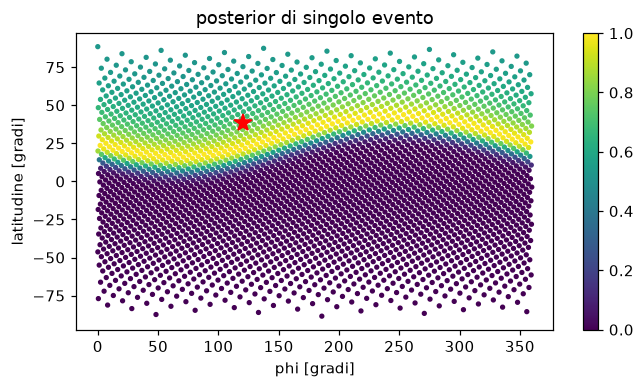

In [2]:
D1 = simulate(1, rng)
lp1 = posterior_B.single_event_posterior(D1, (theta_grid, phi_grid), prior_dir)[0]
fig, ax = plt.subplots(figsize=(7, 3.5))
plt.colorbar(sky(ax, np.exp(lp1 - lp1.max()), "posterior di singolo evento"), ax=ax)
plt.show()

## Combinare N eventi

Ogni evento aggiunge un vincolo, e il posterior combinato si concentra attorno alla direzione vera.
Il combinato si calcola con `posterior_C.shared_direction_log_posterior`, che somma le
log-verosimiglianze del Caso B contando il prior una sola volta.

N=  3: errore del MAP = 6.35 gradi


N= 10: errore del MAP = 7.33 gradi


N=100: errore del MAP = 5.09 gradi


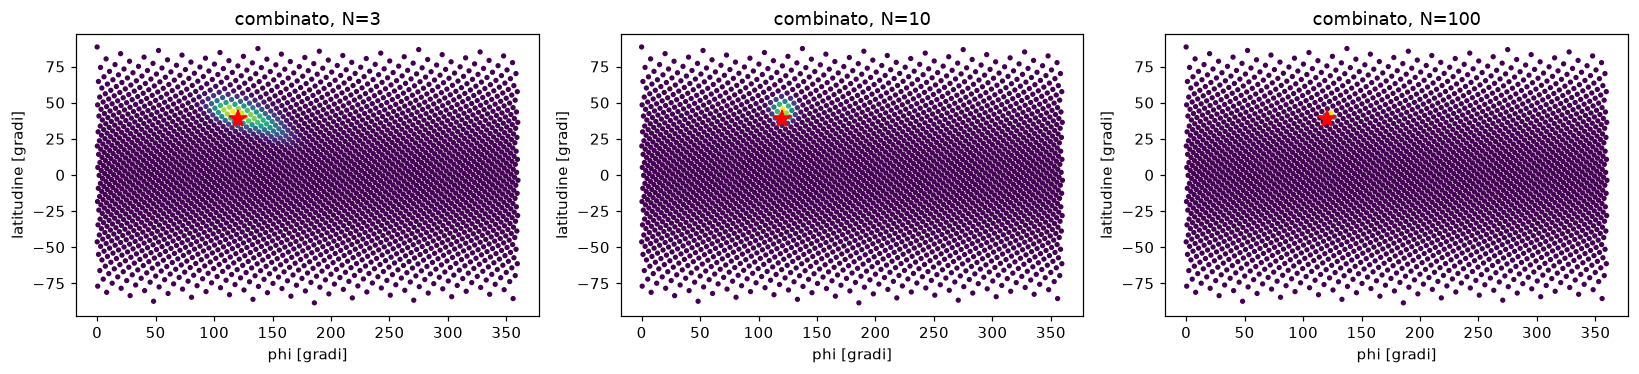

In [3]:
D = simulate(100, rng)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, n in zip(axes, (3, 10, 100)):
    Dn = (D[0][:n], D[1][:n])
    c = posterior_C.shared_direction_log_posterior(Dn, theta_grid, phi_grid, prior_dir)
    sky(ax, np.exp(c - c.max()), f"combinato, N={n}")
    err = validate.angular_residual(OMEGA_TRUE, omega_grid[np.argmax(c)][None, :])[0]
    print(f"N={n:3d}: errore del MAP = {np.degrees(err):.2f} gradi")
plt.tight_layout(); plt.show()

Qui il MAP è letto sulla griglia grossolana (3000 pixel, passo circa 3.7°): a N grande l'errore
resta di qualche grado perché è limitato dalla discretizzazione, non dai dati. Il raffinamento
locale più sotto toglie questo limite.

## Perché serve la risoluzione angolare nella verosimiglianza

Una prima versione del modello aveva due caratteristiche. Considerava la traccia misurata senza
errore angolare e poneva $L_k(\Omega) = -\infty$ quando $\hat\theta > 90^\circ$. Con questa
verosimiglianza, un candidato $\Omega$ sopravvive solo se tutte le $N$ tracce stanno nel suo
emisfero anteriore: l'insieme ammesso è l'intersezione di $N$ emisferi. La direzione vera
soddisfa sempre il vincolo, ma i **pixel** della griglia vicini a essa no. Al crescere di N
l'insieme ammesso si riduce a pochi pixel e, a seconda della realizzazione e del passo della
griglia, può svuotarsi del tutto. In quel caso il combinato vale $-\infty$ ovunque e `np.argmax`
restituisce in silenzio il pixel 0, cioè il polo nord della griglia, lontano dalla verità **(c)**.
Anche quando qualche pixel sopravvive, la stima è decisa dal bordo dell'intersezione e non dalla
forma della verosimiglianza.

Qui sotto si contano i pixel ammessi, anche usando tracce esatte (senza smearing):

In [4]:
for n in (10, 30, 100, 300, 1000):
    counts = []
    for _ in range(8):
        _, track = simulate(n, rng, smear=False)
        ang = kinematics.recoil_angle_from_direction(track, omega_grid)   # (n, 3000)
        counts.append(int(np.sum(np.all(ang <= np.pi / 2, axis=0))))
    print(f"N={n:5d}: pixel con tutte le tracce in avanti (8 realizzazioni) = {counts}")

err_pix0 = validate.angular_residual(OMEGA_TRUE, omega_grid[:1])[0]
print(f"distanza del pixel 0 dalla verita': {np.degrees(err_pix0):.2f} gradi")

N=   10: pixel con tutte le tracce in avanti (8 realizzazioni) = [346, 290, 222, 289, 242, 334, 294, 219]
N=   30: pixel con tutte le tracce in avanti (8 realizzazioni) = [41, 108, 97, 60, 145, 37, 37, 93]
N=  100: pixel con tutte le tracce in avanti (8 realizzazioni) = [9, 16, 35, 9, 62, 32, 20, 16]


N=  300: pixel con tutte le tracce in avanti (8 realizzazioni) = [6, 12, 11, 8, 4, 19, 17, 7]


N= 1000: pixel con tutte le tracce in avanti (8 realizzazioni) = [4, 3, 2, 1, 2, 4, 2, 1]
distanza del pixel 0 dalla verita': 52.32 gradi


Il modello attuale risolve il problema su due fronti:

* **risoluzione angolare nella verosimiglianza**: l'angolo vero viene marginalizzato attorno a
  quello osservato, il taglio netto a 90° diventa morbido e il posterior resta finito su tutta la
  sfera;
* **una guardia**: se il combinato è $-\infty$ ovunque, si solleva un errore invece di restituire
  il pixel 0.

Sugli stessi dati di prima (tracce con smearing), il combinato è finito ovunque:

In [5]:
c = posterior_C.shared_direction_log_posterior(simulate(300, rng), theta_grid, phi_grid, prior_dir)
print(f"pixel finiti: {np.isfinite(c).sum()} / {c.size}")
print(f"errore del MAP a N=300: {np.degrees(validate.angular_residual(OMEGA_TRUE, omega_grid[np.argmax(c)][None, :])[0]):.2f} gradi")

pixel finiti: 3000 / 3000
errore del MAP a N=300: 2.83 gradi


## Contrazione, risoluzione e pull angolare

Con 3000 pixel la griglia ha un passo di circa 3.7°, che a N grande è più largo del posterior. Si
usa quindi il raffinamento locale (`posterior_C.refine_shared_direction`): prima il combinato sulla
griglia grossolana, poi una calotta fine attorno al massimo.

Per ogni N si ripetono M esperimenti e si misurano:

* l'errore angolare del MAP;
* la risoluzione dichiarata dal posterior;
* il pull angolare, cioè errore diviso risoluzione.

Per un ricostruttore calibrato, l'errore scende come $1/\sqrt N$ e il pull ha rms ≈ 1 **(c)**.

N=  10: rms errore  9.55 gradi | risoluzione media 15.53 gradi | rms pull 0.73
N=  30: rms errore  3.87 gradi | risoluzione media  5.09 gradi | rms pull 0.79
N= 100: rms errore  2.55 gradi | risoluzione media  2.66 gradi | rms pull 0.93
N= 300: rms errore  1.36 gradi | risoluzione media  1.48 gradi | rms pull 0.87
pendenza log-log dell'errore: -0.55 (attesa -0.5)


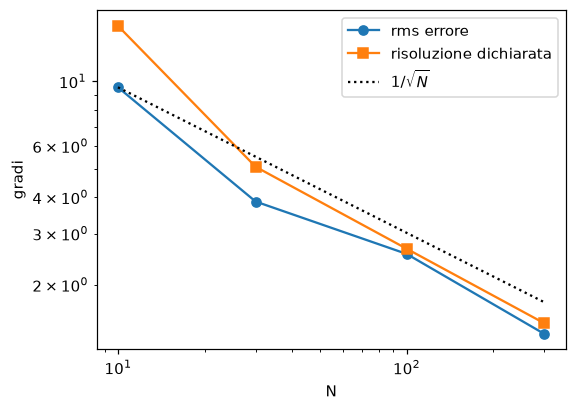

In [6]:
N_VALUES, M = [10, 30, 100, 300], 6
rows = []
for n in N_VALUES:
    for _ in range(M):
        Dn = simulate(n, rng)
        om, cap_lp, cap_th, cap_ph = posterior_C.refine_shared_direction(Dn, theta_grid, phi_grid, prior_dir)
        cap = kinematics.direction_from_theta_phi(cap_th, cap_ph)
        err = validate.angular_residual(OMEGA_TRUE, om)[0]
        res = validate.posterior_angular_resolution(cap_lp[None, :], cap, om)[0]
        rows.append((n, err, res))
rows = np.array(rows)

rms_err, mean_res = [], []
for n in N_VALUES:
    r = rows[rows[:, 0] == n]
    rms_err.append(np.sqrt(np.mean(r[:, 1] ** 2))); mean_res.append(r[:, 2].mean())
    pull = validate.angular_pull(r[:, 1], r[:, 2])
    print(f"N={n:4d}: rms errore {np.degrees(rms_err[-1]):5.2f} gradi | risoluzione media {np.degrees(mean_res[-1]):5.2f} gradi"
          f" | rms pull {np.sqrt(np.mean(pull**2)):.2f}")
slope = np.polyfit(np.log(N_VALUES), np.log(rms_err), 1)[0]
print(f"pendenza log-log dell'errore: {slope:+.2f} (attesa -0.5)")

plt.figure(figsize=(5.5, 4))
plt.loglog(N_VALUES, np.degrees(rms_err), "o-", label="rms errore")
plt.loglog(N_VALUES, np.degrees(mean_res), "s-", label="risoluzione dichiarata")
plt.loglog(N_VALUES, np.degrees(rms_err[0]) * np.sqrt(N_VALUES[0] / np.array(N_VALUES)), "k:", label=r"$1/\sqrt{N}$")
plt.xlabel("N"); plt.ylabel("gradi"); plt.legend(); plt.show()

Nota sul pull angolare: l'errore angolare è una distanza sulla sfera, quindi è non negativo e ha
due componenti. Per un ricostruttore calibrato, errore/risoluzione ha rms ≈ 1 e
$\sqrt2\,\cdot$pull segue una Rayleigh.

Lettura dei numeri: la pendenza è vicina a −0.5 e la risoluzione dichiarata segue l'errore reale.
L'rms del pull resta un po' sotto 1, soprattutto a N piccolo, cioè il posterior è leggermente
conservativo (dichiara un'incertezza un po' più larga dell'errore reale). Con M = 6 ripetizioni per
N le fluttuazioni su questo numero sono però ampie; la statistica completa è nel notebook 05.